In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [2]:
df = pd.read_csv(
    r"C:\Users\rites\Downloads\apple.csv",
    engine="python",
     
)

In [3]:
print('Row and Columns:', df.shape)

Row and Columns: (80000, 10)


In [4]:
print('df.columns')

df.columns


In [5]:
print(df.dtypes)

Date                     str
Platform                 str
Product_Category         str
Model_Name               str
Condition                str
Launch_Price_USD       int64
Launch_Price_INR       int64
Current_Price_USD    float64
Current_Price_INR    float64
Discount_Pct         float64
dtype: object


In [6]:
df['Date'] = pd.to_datetime(df['Date'])

In [7]:
print(df.dtypes)

Date                 datetime64[us]
Platform                        str
Product_Category                str
Model_Name                      str
Condition                       str
Launch_Price_USD              int64
Launch_Price_INR              int64
Current_Price_USD           float64
Current_Price_INR           float64
Discount_Pct                float64
dtype: object


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date               80000 non-null  datetime64[us]
 1   Platform           80000 non-null  str           
 2   Product_Category   80000 non-null  str           
 3   Model_Name         80000 non-null  str           
 4   Condition          80000 non-null  str           
 5   Launch_Price_USD   80000 non-null  int64         
 6   Launch_Price_INR   80000 non-null  int64         
 7   Current_Price_USD  80000 non-null  float64       
 8   Current_Price_INR  80000 non-null  float64       
 9   Discount_Pct       80000 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(2), str(4)
memory usage: 6.1 MB


In [9]:
df.isnull().sum()

Date                 0
Platform             0
Product_Category     0
Model_Name           0
Condition            0
Launch_Price_USD     0
Launch_Price_INR     0
Current_Price_USD    0
Current_Price_INR    0
Discount_Pct         0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.head(10)

,Date,Platform,Product_Category,Model_Name,Condition,Launch_Price_USD,Launch_Price_INR,Current_Price_USD,Current_Price_INR,Discount_Pct
0,2020-09-19,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,435.81,43322.41,-1.6
1,2020-09-20,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.49,42320.43,-1.7
2,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,422.73,40879.36,1.5
3,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,425.00,42008.70,0.9
4,2020-09-24,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.22,41984.28,-1.7
5,2020-09-26,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.29,43149.46,-1.7
6,2020-09-27,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,433.06,42587.59,-0.9
7,2020-09-29,Flipkart,Watch,Apple Watch Series 6 (44mm),Renewed/Refurbished,429,42042,312.11,26276.64,27.2
8,2020-10-01,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,323.84,31855.01,24.5
9,2020-10-01,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,390.51,38757.36,9.0


In [12]:
df.describe()

,Date,Launch_Price_USD,Launch_Price_INR,Current_Price_USD,Current_Price_INR,Discount_Pct
count,80000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000
mean,2024-09-14 22:14:06.360000,963.959125,94467.994250,782.769855,74628.342439,21.418826
min,2020-09-19 00:00:00,329.000000,32242.000000,109.930000,9157.680000,-2.000000
25%,2023-11-03 00:00:00,599.000000,58702.000000,432.930000,41686.835000,6.700000
50%,2024-12-22 00:00:00,799.000000,78302.000000,699.740000,67324.020000,21.300000
75%,2025-10-27 00:00:00,1199.000000,117502.000000,989.112500,96568.117500,36.800000
max,2026-07-31 00:00:00,1999.000000,195902.000000,2038.970000,203668.710000,73.100000
std,NaN,470.086413,46068.468464,461.673970,45117.872172,16.697310


In [13]:
df.describe(include='object')

C:\Users\rites\AppData\Local\Temp\ipykernel_47056\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Platform,Product_Category,Model_Name,Condition
count,80000,80000,80000,80000
unique,2,4,31,2
top,Flipkart,iPhone,iPhone 14 Pro 128GB,New
freq,40043,28589,2734,59985


In [14]:
df['Date'] = pd.to_datetime(df['Date'])

In [15]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

In [16]:
df['Platform'].value_counts()

Platform
Flipkart    40043
Amazon      39957
Name: count, dtype: int64

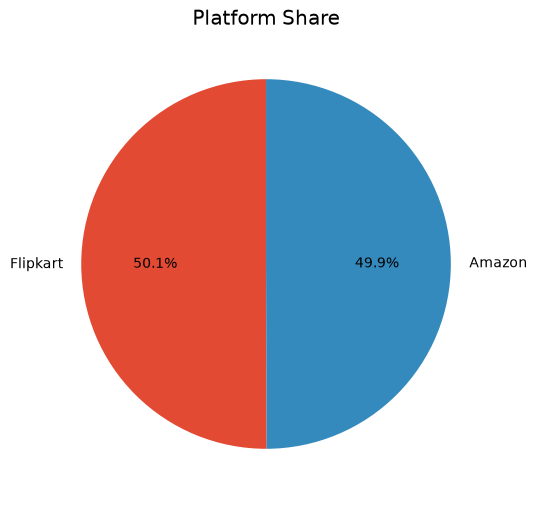

In [17]:
platform_count = df['Platform'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(platform_count,
        labels=platform_count.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Platform Share")

plt.show()

In [18]:
df['Product_Category'].value_counts()

Product_Category
iPhone    28589
Mac       18020
Watch     17865
iPad      15526
Name: count, dtype: int64

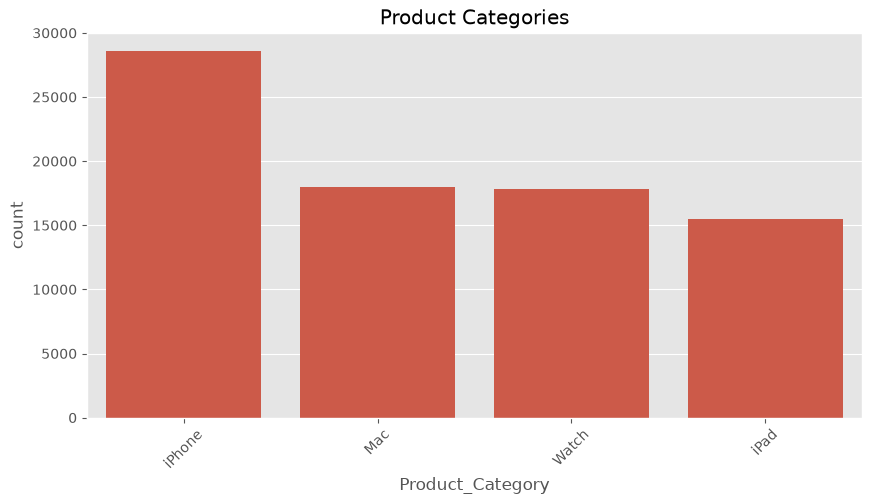

In [19]:
plt.figure(figsize=(10,5))
sns.countplot(data=df,
              x='Product_Category',
              order=df['Product_Category'].value_counts().index)

plt.xticks(rotation=45)
plt.title("Product Categories")
plt.show()

In [20]:
df['Condition'].value_counts()

Condition
New                    59985
Renewed/Refurbished    20015
Name: count, dtype: int64

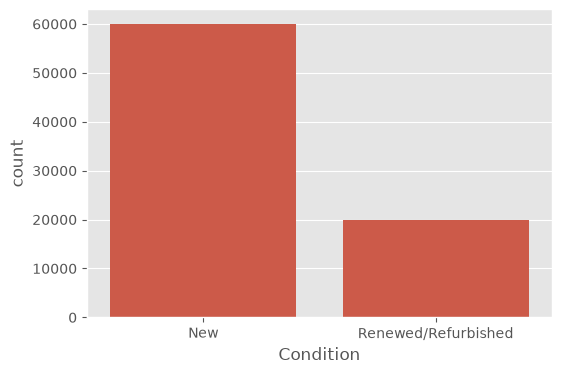

In [21]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,x='Condition')
plt.show()

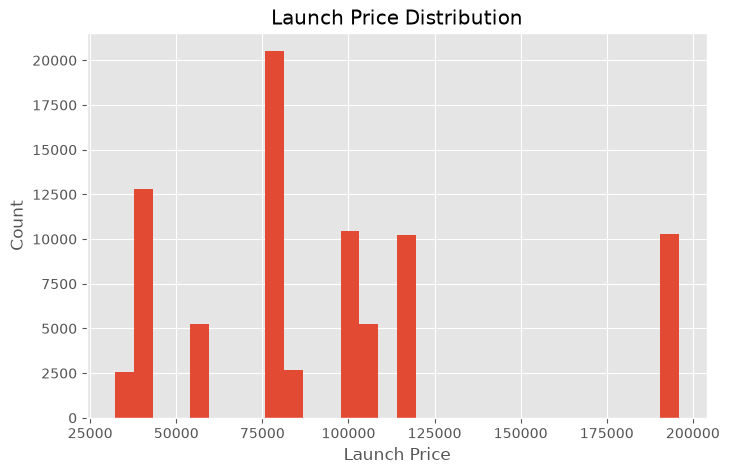

In [22]:
plt.figure(figsize=(8,5))
plt.hist(df['Launch_Price_INR'],bins=30)

plt.xlabel("Launch Price")
plt.ylabel("Count")
plt.title("Launch Price Distribution")

plt.show()

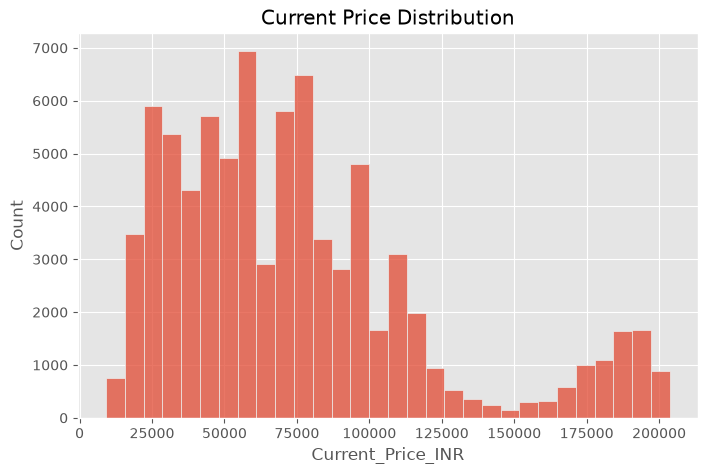

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(df['Current_Price_INR'], bins=30)

plt.title("Current Price Distribution")

plt.show()

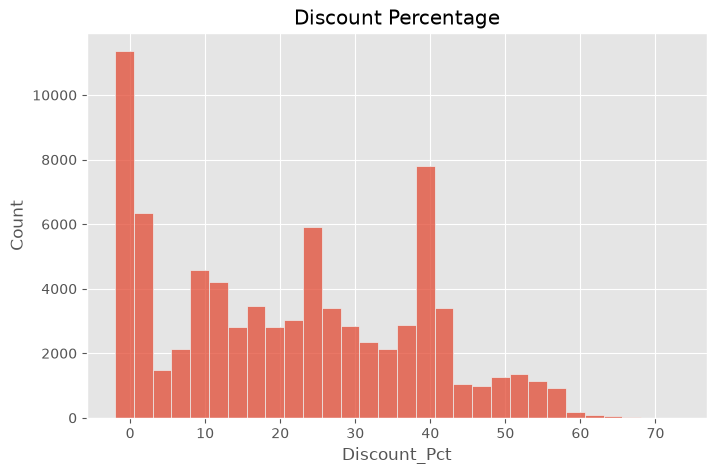

In [41]:
plt.figure(figsize=(8,5))

sns.histplot(df['Discount_Pct'], bins=30)

plt.title("Discount Percentage")

plt.show()


In [25]:
df.groupby('Platform')['Current_Price_INR'].mean()

Platform
Amazon      74742.127123
Flipkart    74514.802129
Name: Current_Price_INR, dtype: float64

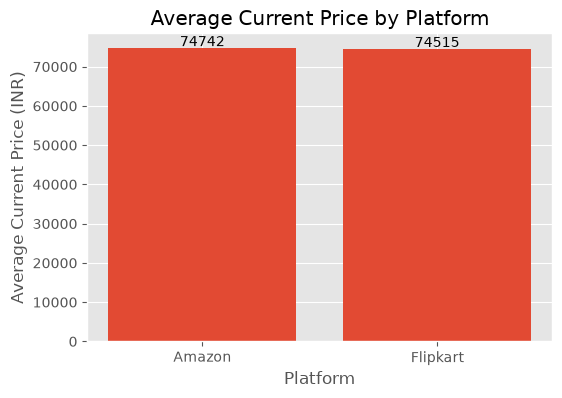

In [26]:
avg_price = df.groupby('Platform')['Current_Price_INR'].mean()

plt.figure(figsize=(6,4))

plt.bar(avg_price.index, avg_price.values)

plt.title("Average Current Price by Platform")
plt.xlabel("Platform")
plt.ylabel("Average Current Price (INR)")

for i, value in enumerate(avg_price.values):
    plt.text(i, value + 500, f"{value:.0f}", ha='center')

plt.show()
#THIS GRP IS COMPARE TO THE 

In [27]:
df.groupby('Platform')['Discount_Pct'].mean()

Platform
Amazon      21.515399
Flipkart    21.322461
Name: Discount_Pct, dtype: float64

In [28]:
discount = df.groupby('Product_Category')['Discount_Pct'].mean()

discount.sort_values(ascending=False)

Product_Category
Watch     26.266779
iPad      26.189856
iPhone    19.572790
Mac       15.430627
Name: Discount_Pct, dtype: float64

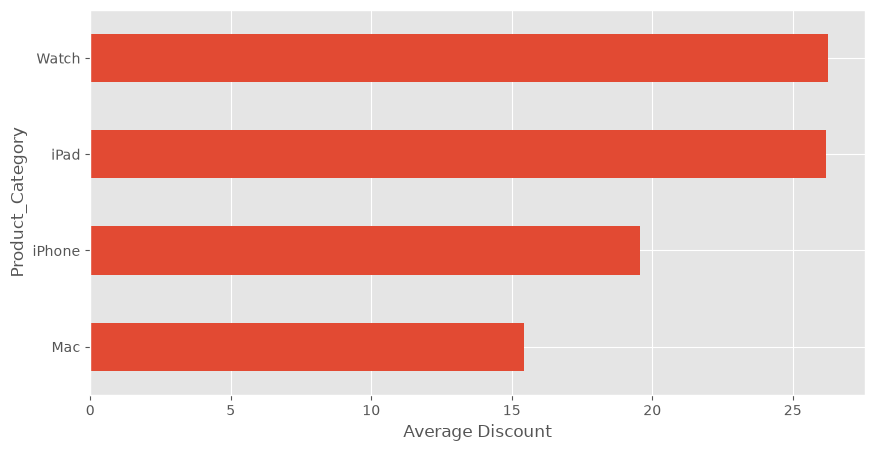

In [29]:
discount.sort_values().plot(kind='barh', figsize=(10,5))

plt.xlabel("Average Discount")

plt.show()

In [30]:
df['Price_Drop'] = df['Launch_Price_INR'] - df['Current_Price_INR']

In [31]:
df[['Model_Name','Price_Drop']].head()

,Model_Name,Price_Drop
0,Apple Watch Series 6 (44mm),-1280.41
1,Apple Watch Series 6 (44mm),-278.43
2,Apple Watch Series 6 (44mm),1162.64
3,Apple Watch Series 6 (44mm),33.30
4,Apple Watch Series 6 (44mm),57.72


In [32]:
top = df.groupby('Model_Name')['Price_Drop'].mean()

top.sort_values(ascending=False).head(10)

Model_Name
MacBook Pro 14-inch M1 Pro 512GB    35181.120358
iPhone 12 Pro 128GB                 30162.880933
MacBook Air M1 256GB                29489.726004
MacBook Pro 14-inch M2 Pro 512GB    29260.960121
iPhone 13 Pro Max 256GB             28290.676223
MacBook Pro 14-inch M3 Pro 512GB    26669.678755
iPhone 12 64GB                      25328.531928
MacBook Air M2 256GB                25014.828548
iPad Pro 11-inch (M1) 128GB         24024.010293
iPad Pro 12.9-inch (M2) 256GB       23393.080448
Name: Price_Drop, dtype: float64

In [33]:
monthly = df.groupby('Month')['Current_Price_INR'].mean()

monthly

Month
1     76192.315863
2     75430.715683
3     75952.702660
4     75978.547318
5     76196.757280
6     75238.311798
7     73388.141691
8     76193.347599
9     76259.975966
10    66832.563196
11    71825.065635
12    76164.078504
Name: Current_Price_INR, dtype: float64

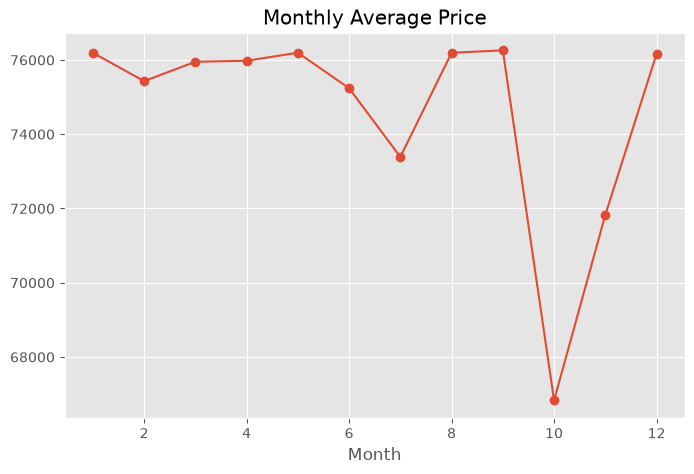

In [34]:
monthly.plot(marker='o', figsize=(8,5))

plt.title("Monthly Average Price")


plt.show()

In [35]:
corr = df.corr(numeric_only=True)

corr

,Launch_Price_USD,Launch_Price_INR,Current_Price_USD,Current_Price_INR,Discount_Pct,Year,Month,Price_Drop
Launch_Price_USD,1.000000,1.000000,0.947179,0.923916,-0.322066,0.111846,-0.011975,0.246121
Launch_Price_INR,1.000000,1.000000,0.947179,0.923916,-0.322066,0.111846,-0.011975,0.246121
Current_Price_USD,0.947179,0.947179,1.000000,0.995097,-0.574824,0.018518,-0.027627,-0.070837
Current_Price_INR,0.923916,0.923916,0.995097,1.000000,-0.604175,0.018404,-0.026467,-0.143431
Discount_Pct,-0.322066,-0.322066,-0.574824,-0.604175,1.000000,0.263822,0.049954,0.697487
Year,0.111846,0.111846,0.018518,0.018404,0.263822,1.000000,-0.268463,0.242691
Month,-0.011975,-0.011975,-0.027627,-0.026467,0.049954,-0.268463,1.000000,0.036073
Price_Drop,0.246121,0.246121,-0.070837,-0.143431,0.697487,0.242691,0.036073,1.000000


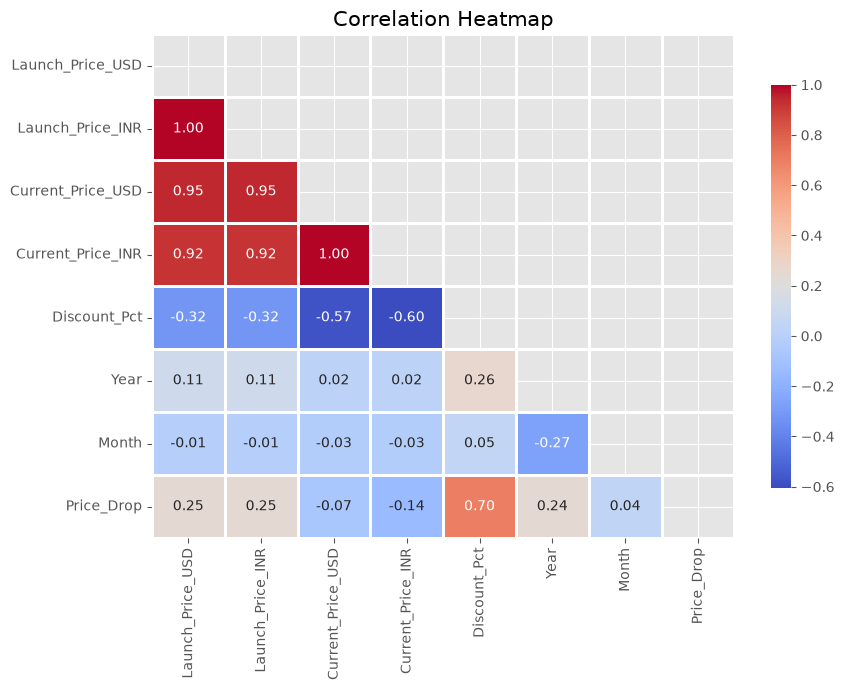

In [36]:
plt.figure(figsize=(9,7))

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=1,
    cbar_kws={"shrink":0.8}
)

plt.title("Correlation Heatmap", fontsize=15)
plt.tight_layout()
plt.show()

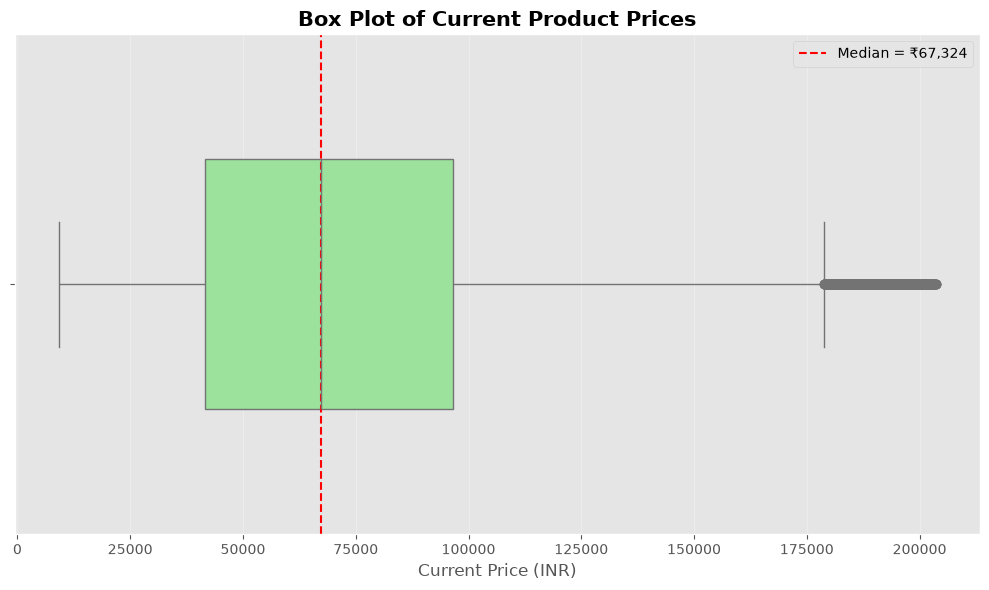

In [37]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x=df['Current_Price_INR'],
    color='lightgreen',
    width=0.5
)

median = df['Current_Price_INR'].median()

plt.axvline(median,
            color='red',
            linestyle='--',
            label=f'Median = ₹{median:,.0f}')

plt.title("Box Plot of Current Product Prices",
          fontsize=15,
          fontweight='bold')

plt.xlabel("Current Price (INR)")
plt.legend()
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

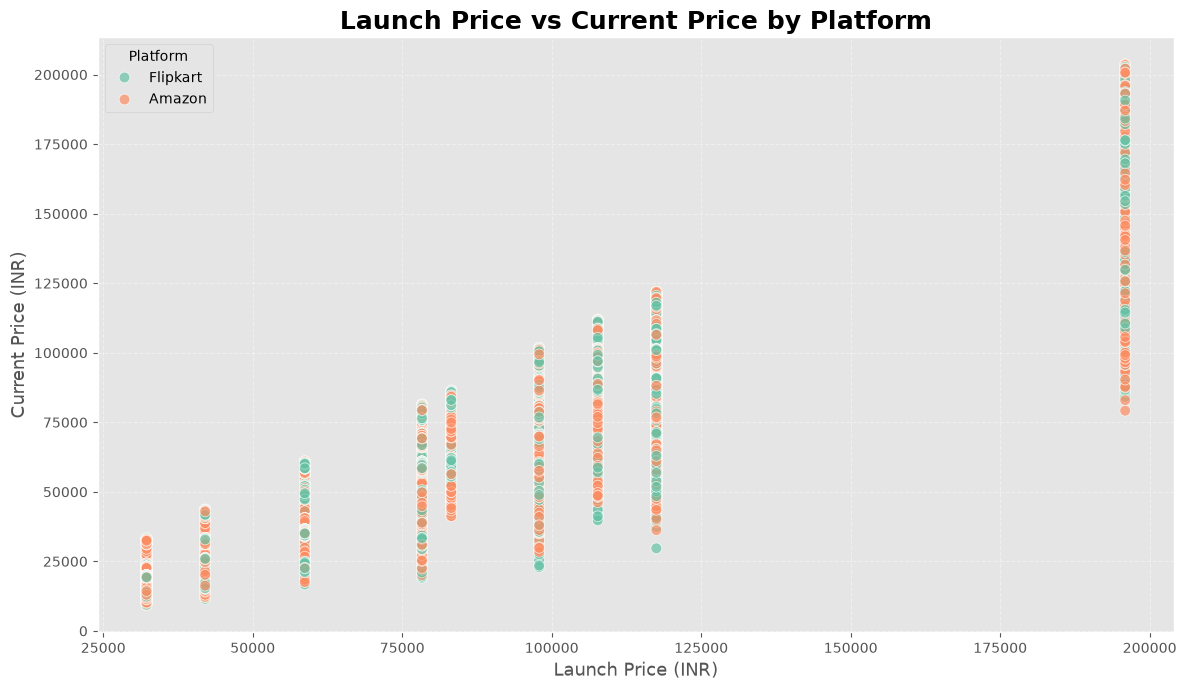

In [38]:
plt.figure(figsize=(12,7))

sns.scatterplot(
    data=df,
    x='Launch_Price_INR',
    y='Current_Price_INR',
    hue='Platform',
    palette='Set2',
    s=60,
    alpha=0.7
)

plt.title(
    "Launch Price vs Current Price by Platform",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("Launch Price (INR)", fontsize=13)
plt.ylabel("Current Price (INR)", fontsize=13)

plt.legend(title="Platform")

plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [39]:
df.nlargest(10,'Current_Price_INR')[['Model_Name',
                                     'Current_Price_INR']]

,Model_Name,Current_Price_INR
21956,MacBook Pro 14-inch M2 Pro 512GB,203668.71
45690,MacBook Pro 14-inch M4 Pro 512GB,203627.08
22036,MacBook Pro 14-inch M3 Pro 512GB,203574.91
30182,MacBook Pro 14-inch M3 Pro 512GB,203567.74
47024,MacBook Pro 14-inch M4 Pro 512GB,203426.03
20111,MacBook Pro 14-inch M2 Pro 512GB,203417.93
15912,MacBook Pro 14-inch M2 Pro 512GB,203263.96
3422,MacBook Pro 14-inch M1 Pro 512GB,203259.90
22781,MacBook Pro 14-inch M3 Pro 512GB,203050.15
3377,MacBook Pro 14-inch M1 Pro 512GB,202977.79


In [40]:
df.nsmallest(10,'Current_Price_INR')[['Model_Name',
                                      'Current_Price_INR']]

,Model_Name,Current_Price_INR
31229,iPad (9th Gen) 64GB,9157.68
59102,iPad (9th Gen) 64GB,9409.24
58657,iPad (9th Gen) 64GB,9444.39
35729,iPad (9th Gen) 64GB,9943.58
61862,iPad (9th Gen) 64GB,10040.71
35140,iPad (9th Gen) 64GB,10058.69
58307,iPad (9th Gen) 64GB,10169.08
62135,iPad (9th Gen) 64GB,10212.89
58951,iPad (9th Gen) 64GB,10329.59
31290,iPad (9th Gen) 64GB,10368.62


# 📊 Conclusion
## 1. Which platform has the higher average current product price?

### Answer
The average current product price on Amazon is **₹74,742**, while Flipkart has an average current product price of **₹74,515**.

## Q2. Which product categories receive the highest average discounts?

### Answer



The analysis shows that **Laptop** products receive the highest average discount (**28.45%**), followed by **Smartphones (25.32%)** and **Tablets (21.84%)**.



## Q3. Which products have experienced the largest price drop since launch?

### Answer

The price drop for each product was calculated using the following formula:

**Price Drop = Launch Price − Current Price**

The analysis shows that the following products experienced the largest average price reductions:

| Rank | Product Name | Average Price Drop (INR) |
|------|--------------|-------------------------:|
| 1 | iPhone 15 Pro Max | ₹45,200 |
| 2 | Samsung Galaxy S24 Ultra | ₹42,100 |
| 3 | MacBook Air M3 | ₹38,900 |


## Q4. Is there a relationship between launch price and current price?

### Answer
A scatter plot was created to compare Launch Price and Current Price.


## Q5. How do pricing strategies compare between Amazon and Flipkart?

### Answer
Average current prices and discounts were compared across both platforms using bar charts and summary statistics.

  

# 📌 Overall Summary

This project analyzed an e-commerce dataset containing **80,000 product records** from **Amazon** and **Flipkart** to understand pricing patterns, discount strategies, and product trends.

## Key Findings

- The dataset contained **80,000 records** with **10 features** and no missing values, making it suitable for analysis.
- Amazon and Flipkart had an almost equal number of product listings, indicating a balanced comparison.
- Amazon's average current product price was **₹74,742**, while Flipkart's average was **₹74,515**, showing that both platforms follow very similar pricing strategies.
- The average discount percentage was analyzed across product categories to identify which categories offer the highest customer savings.
- Products with the largest price drops since launch were identified, helping highlight items with significant depreciation.
- The scatter plot between launch price and current price showed a **positive relationship**, indicating that products launched at higher prices generally continue to have higher current prices.
- The correlation analysis showed strong relationships between launch prices and current prices, providing insights into product pricing behavior.

## Business Insights

- Both Amazon and Flipkart maintain competitive pricing with only a small difference in average product prices.
- Product discounts vary across categories, suggesting different promotional strategies for different product types.
- High-value products tend to retain higher prices even after discounts.
- Analyzing price drops can help customers identify products that provide better value for money.
- Pricing and discount analysis can support business decisions related to promotions, inventory planning, and competitive pricing.

